### Making The Model to predict the Toxic Comments on Women Post

### EDA To Check Any Missing VAlue

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df=pd.read_csv('../data/processed/final_training_dataset.csv')

In [33]:
df.head(10)

,id,comment,label,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,generated_9904605622885591,Achi acting karke prove karo apne aap ko fir k...,0,0,0,0,0,0,0
1,generated_9904605622885592,Then y your leg ...one above one😂😂😂😂seedha bat...,0,0,0,0,0,0,0
2,generated_9904605622885593,Ok go ahead reveal as much you want. If men st...,0,0,0,0,0,0,0
3,generated_9904605622885594,Ye bhi mat pehno Koi problem nahi Hope it's fine,0,0,0,0,0,0,0
4,generated_9904605622885595,Roger Federer!!,0,0,0,0,0,0,0
5,generated_9904605622885596,Ppl forget ye india h pak ya afganistan nhi h 😂,0,0,0,0,0,0,0
6,generated_9904605622885597,Hame koyi problem nahi to porn industry bhi Ch...,0,0,0,0,0,0,0
7,generated_9904605622885598,She's beautiful and should be able to wear wha...,0,0,0,0,0,0,0
8,generated_9904605622885599,because you are role models for some and they ...,0,0,0,0,0,0,0
9,generated_9904605622885600,YES there is a problem 😢😢😢this halfway naked t...,0,0,0,0,0,0,0


In [34]:
df.isnull().sum()

id               0
comment          0
label            0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [35]:
df.duplicated().sum()

0

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177875 entries, 0 to 177874
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             177875 non-null  object
 1   comment        177875 non-null  object
 2   label          177875 non-null  int64 
 3   toxic          177875 non-null  int64 
 4   severe_toxic   177875 non-null  int64 
 5   obscene        177875 non-null  int64 
 6   threat         177875 non-null  int64 
 7   insult         177875 non-null  int64 
 8   identity_hate  177875 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 12.2+ MB


In [38]:
df.describe()

,label,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,177875.000000,177875.000000,177875.000000,177875.000000,177875.000000,177875.000000,177875.000000
mean,0.180869,0.105001,0.009945,0.053746,0.011227,0.044655,0.014342
std,0.384910,0.306555,0.099229,0.225516,0.105361,0.206546,0.118895
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [39]:
labels_counts=df.columns

In [40]:
labels_counts

Index(['id', 'comment', 'label', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [41]:
len(labels_counts)

9

In [42]:
rows_count=df.shape

In [43]:
rows_count

(177875, 9)

In [44]:
## Droping the 'id' column as it is not needed for prediction
df.drop(columns=['id'], inplace=True)

In [45]:
df.head(10)

,comment,label,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Achi acting karke prove karo apne aap ko fir k...,0,0,0,0,0,0,0
1,Then y your leg ...one above one😂😂😂😂seedha bat...,0,0,0,0,0,0,0
2,Ok go ahead reveal as much you want. If men st...,0,0,0,0,0,0,0
3,Ye bhi mat pehno Koi problem nahi Hope it's fine,0,0,0,0,0,0,0
4,Roger Federer!!,0,0,0,0,0,0,0
5,Ppl forget ye india h pak ya afganistan nhi h 😂,0,0,0,0,0,0,0
6,Hame koyi problem nahi to porn industry bhi Ch...,0,0,0,0,0,0,0
7,She's beautiful and should be able to wear wha...,0,0,0,0,0,0,0
8,because you are role models for some and they ...,0,0,0,0,0,0,0
9,YES there is a problem 😢😢😢this halfway naked t...,0,0,0,0,0,0,0


In [46]:
labels_counts=df.columns

## Visulaizing the Data to Check how many Toxic,obscene,threat etc in dataset

In [47]:
label_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
labels_counts = df[label_columns].sum()

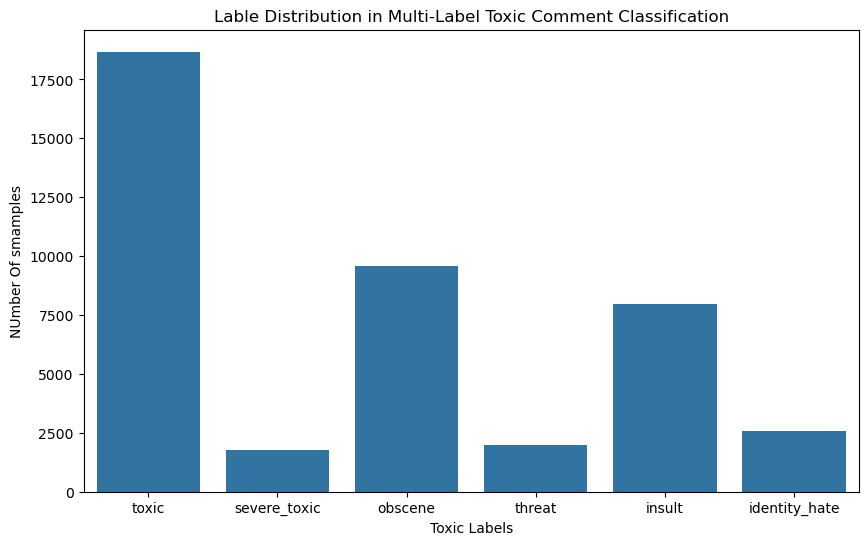

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.title("Lable Distribution in Multi-Label Toxic Comment Classification")
sns.barplot(x=labels_counts.index, y=labels_counts.values)
plt.ylabel("NUmber Of smamples")
plt.xlabel("Toxic Labels")
plt.show()

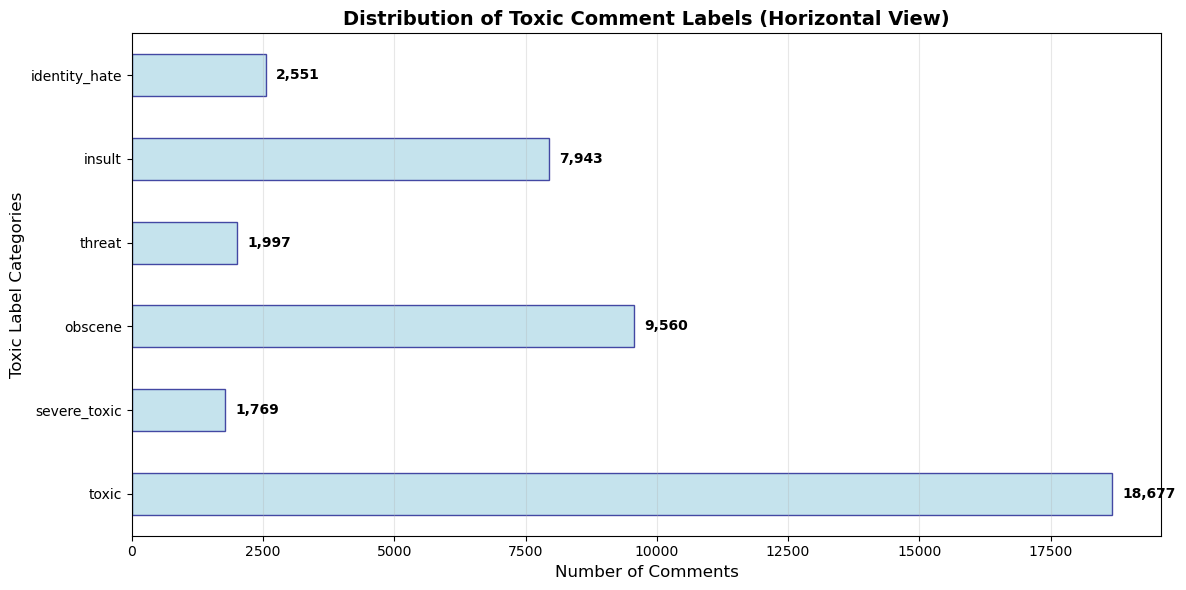

In [49]:
plt.figure(figsize=(12, 6))

# Create horizontal bar chart with proper method call
ax = labels_counts.plot(kind='barh', color='lightblue', edgecolor='navy', alpha=0.7)

plt.title("Distribution of Toxic Comment Labels (Horizontal View)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Comments", fontsize=12)
plt.ylabel("Toxic Label Categories", fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Add value labels on the bars
for i, (label, value) in enumerate(labels_counts.items()):
    plt.text(value + 200, i, f'{value:,}', va='center', ha='left', fontweight='bold')

plt.tight_layout()
plt.show()


## Now Convert all the Text Into Vector

Using The Ollama Encoding For the Text Conversion into Vector Because it effective Than the Word2vec,NLTK,TF-IDF,Label Encoding and reqired Less Amount of time and Its easy to use if You Have an good GPU if not i preffer Using word2Vec Because its Better than any of this

In [50]:
df.head(5)

,comment,label,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Achi acting karke prove karo apne aap ko fir k...,0,0,0,0,0,0,0
1,Then y your leg ...one above one😂😂😂😂seedha bat...,0,0,0,0,0,0,0
2,Ok go ahead reveal as much you want. If men st...,0,0,0,0,0,0,0
3,Ye bhi mat pehno Koi problem nahi Hope it's fine,0,0,0,0,0,0,0
4,Roger Federer!!,0,0,0,0,0,0,0


In [51]:
## First Dividing My Feature Into X And Y
#X is for Input Features
X=df['comment'].astype('str')
## Y Is for Output Features
label_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
Y=df[label_columns]

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Y columns: {list(Y.columns)}")

X shape: (177875,)
Y shape: (177875, 6)
Y columns: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [52]:
from dotenv import load_dotenv
load_dotenv()

import requests
import time
import numpy as np

## Check if Ollama is running
def check_ollama_connection():
    try:
        response = requests.get("http://localhost:11434/api/tags", timeout=5)
        if response.status_code == 200:
            print("Ollama is running!")
            return True
        else:
            print("Ollama is not responding properly")
            return False
    except requests.exceptions.RequestException:
        print("Ollama is not running on localhost:11434")
        print(" To fix this:")
        print("1. Install Ollama from: https://ollama.ai")
        print("2. Run: ollama serve")
        print("3. Run: ollama pull nomic-embed-text")
        return False

# Check connection
ollama_available = check_ollama_connection()

if ollama_available:
    ## Using Ollama Embeddings For Text Embeddings
    from langchain_community.embeddings import OllamaEmbeddings
    
    embedding = OllamaEmbeddings(model="mxbai-embed-large:latest")
    print("Ollama embeddings initialized!")
    
    ## Converting X(a Pandas Series) to a list of strings
    texts = X.tolist()
    print(type(texts), len(texts))

    
else:
    print("⚠️ Using fallback: Word2Vec embeddings")
    from gensim.models import Word2Vec
    from nltk.tokenize import word_tokenize
    import nltk
    
    # Download required NLTK data
    try:
        nltk.data.find('tokenizers/punkt')
    except LookupError:
        print("Downloading NLTK punkt tokenizer...")
        nltk.download('punkt')
    
    # Initialize Word2Vec variables
    embedding = None
    texts = X.tolist()
    
    print("🔄 Preparing texts for Word2Vec training...")
    # Tokenize texts for Word2Vec
    tokenized_texts = [word_tokenize(text.lower()) for text in texts[:1000]]  # Limit for demo
    
    print("🤖 Training Word2Vec model...")
    word2vec_model = Word2Vec(
        sentences=tokenized_texts,
        vector_size=300,        # Embedding dimension
        window=5,               # Context window size
        min_count=2,           # Ignore words with frequency < 2
        workers=4,             # Number of CPU cores
        epochs=10              # Training epochs
    )
    
    print(f" Word2Vec model trained with {len(word2vec_model.wv)} unique words")

Ollama is running!
Ollama embeddings initialized!
<class 'list'> 177875


In [53]:
print(type(texts), len(texts))
print(texts[:2])  # show first two entries


<class 'list'> 177875
['Achi acting karke prove karo apne aap ko fir kuch bhi pehno, no one will say anything 😁', 'Then y your leg ...one above one😂😂😂😂seedha batih....no shame ...']


In [54]:
# Word2vec Embedding
import numpy as np
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
import time
from multiprocessing import cpu_count
import re
from tqdm import tqdm
import pickle
import os

# Configuration
VECTOR_SIZE = 300
WINDOW_SIZE = 5
MIN_COUNT = 2
WORKERS = cpu_count()
SG = 1  # Skip-gram model
EPOCHS = 10

print(f"Starting Word2Vec embedding generation...")
print(f"Dataset size: {len(X)} comments")
print(f"Using {WORKERS} workers for training")

# Text preprocessing function
def preprocess_text(text):
    """Clean and tokenize text for Word2Vec training."""
    if pd.isna(text):
        return []
    
    # Convert to lowercase and remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    
    # Tokenize using gensim's simple_preprocess
    tokens = simple_preprocess(text, deacc=True, min_len=2, max_len=15)
    
    return tokens

# Tokenize all texts
print("Tokenizing texts...")
start_time = time.time()

# Process texts in batches for memory efficiency
tokenized_texts = []
batch_size = 5000

for i in tqdm(range(0, len(X), batch_size), desc="Tokenizing"):
    batch = X.iloc[i:i+batch_size]
    batch_tokens = [preprocess_text(text) for text in batch]
    tokenized_texts.extend(batch_tokens)

tokenization_time = time.time() - start_time
print(f"Tokenization completed in {tokenization_time:.2f} seconds")
print(f"Average tokens per text: {np.mean([len(tokens) for tokens in tokenized_texts if tokens]):.1f}")

# Train Word2Vec model
print("\nTraining Word2Vec model...")
start_time = time.time()

# Create and train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    workers=WORKERS,
    sg=SG,
    epochs=EPOCHS,
    seed=42
)

training_time = time.time() - start_time
print(f"Word2Vec training completed in {training_time:.2f} seconds")
print(f"Vocabulary size: {len(w2v_model.wv.key_to_index)}")

# Generate embeddings for all texts
print("\nGenerating embeddings...")
start_time = time.time()

def get_text_embedding(tokens, model):
    """Generate embedding for a text by averaging word vectors."""
    if not tokens:
        return np.zeros(VECTOR_SIZE)
    
    # Get word vectors for tokens that exist in vocabulary
    word_vectors = []
    for token in tokens:
        if token in model.wv:
            word_vectors.append(model.wv[token])
    
    if not word_vectors:
        return np.zeros(VECTOR_SIZE)
    
    # Average the word vectors
    return np.mean(word_vectors, axis=0)

# Generate embeddings in batches
embeddings = []
batch_size = 1000

for i in tqdm(range(0, len(tokenized_texts), batch_size), desc="Generating embeddings"):
    batch_tokens = tokenized_texts[i:i+batch_size]
    batch_embeddings = [get_text_embedding(tokens, w2v_model) for tokens in batch_tokens]
    embeddings.extend(batch_embeddings)

# Convert to numpy array
X_embeddings = np.array(embeddings)

embedding_time = time.time() - start_time
total_time = tokenization_time + training_time + embedding_time

print(f"\nEmbedding generation completed!")
print(f"Embedding generation time: {embedding_time:.2f} seconds")
print(f"Total processing time: {total_time:.2f} seconds")
print(f"Processing speed: {len(X)/total_time:.2f} texts/sec")
print(f"Embedding shape: {X_embeddings.shape}")

# Verify embeddings
non_zero_embeddings = np.count_nonzero(np.any(X_embeddings != 0, axis=1))
print(f"Non-zero embeddings: {non_zero_embeddings}/{len(X_embeddings)} ({100*non_zero_embeddings/len(X_embeddings):.1f}%)")

# Save the model and embeddings
model_dir = "../output/models"
os.makedirs(model_dir, exist_ok=True)

# Save Word2Vec model
w2v_model.save(os.path.join(model_dir, "word2vec_model.model"))
print(f"Word2Vec model saved to {model_dir}/word2vec_model.model")

# Save embeddings
np.save(os.path.join(model_dir, "embeddings.npy"), X_embeddings)
print(f"Embeddings saved to {model_dir}/embeddings.npy")

# Save preprocessing info
preprocessing_info = {
    'vector_size': VECTOR_SIZE,
    'vocabulary_size': len(w2v_model.wv.key_to_index),
    'total_texts': len(X),
    'processing_time': total_time,
    'processing_speed': len(X)/total_time
}

with open(os.path.join(model_dir, "preprocessing_info.pkl"), "wb") as f:
    pickle.dump(preprocessing_info, f)

print(f"Preprocessing info saved to {model_dir}/preprocessing_info.pkl")
print("\nWord2Vec embedding generation completed successfully!")

Starting Word2Vec embedding generation...
Dataset size: 177875 comments
Using 16 workers for training
Tokenizing texts...


Tokenizing: 100%|██████████| 36/36 [00:12<00:00,  2.91it/s]



Tokenization completed in 12.48 seconds
Average tokens per text: 57.9

Training Word2Vec model...
Word2Vec training completed in 60.29 seconds
Vocabulary size: 93433

Generating embeddings...
Word2Vec training completed in 60.29 seconds
Vocabulary size: 93433

Generating embeddings...


Generating embeddings: 100%|██████████| 178/178 [00:14<00:00, 12.39it/s]




Embedding generation completed!
Embedding generation time: 14.57 seconds
Total processing time: 87.34 seconds
Processing speed: 2036.50 texts/sec
Embedding shape: (177875, 300)
Non-zero embeddings: 176937/177875 (99.5%)
Word2Vec model saved to ../output/models/word2vec_model.model
Word2Vec model saved to ../output/models/word2vec_model.model
Embeddings saved to ../output/models/embeddings.npy
Preprocessing info saved to ../output/models/preprocessing_info.pkl

Word2Vec embedding generation completed successfully!
Embeddings saved to ../output/models/embeddings.npy
Preprocessing info saved to ../output/models/preprocessing_info.pkl

Word2Vec embedding generation completed successfully!


In [55]:
# Verify the NumPy array embeddings
print("=== EMBEDDINGS NUMPY ARRAY VERIFICATION ===")
print(f"Variable type: {type(X_embeddings)}")
print(f"Array shape: {X_embeddings.shape}")
print(f"Array dtype: {X_embeddings.dtype}")
print(f"Memory usage: {X_embeddings.nbytes / (1024**2):.2f} MB")
print(f"First embedding sample (first 10 values): {X_embeddings[0][:10]}")
print(f"Array statistics:")
print(f"  Mean: {np.mean(X_embeddings):.6f}")
print(f"  Std: {np.std(X_embeddings):.6f}")
print(f"  Min: {np.min(X_embeddings):.6f}")
print(f"  Max: {np.max(X_embeddings):.6f}")

# Check saved file
import os
saved_file = "../output/models/embeddings.npy"
if os.path.exists(saved_file):
    file_size = os.path.getsize(saved_file) / (1024**2)
    print(f"\nSaved file: {saved_file}")
    print(f"File size: {file_size:.2f} MB")
    
    # Verify we can load it back
    loaded_embeddings = np.load(saved_file)
    print(f"Loaded shape: {loaded_embeddings.shape}")
    print(f"Arrays match: {np.array_equal(X_embeddings, loaded_embeddings)}")
else:
    print(f"❌ File not found: {saved_file}")

print("\n🎉 Your embeddings are ready as NumPy array for ML training!")

=== EMBEDDINGS NUMPY ARRAY VERIFICATION ===
Variable type: <class 'numpy.ndarray'>
Array shape: (177875, 300)
Array dtype: float64
Memory usage: 407.12 MB
First embedding sample (first 10 values): [ 0.02491248  0.08854457 -0.05051008  0.10843278 -0.16341025  0.20318502
 -0.15457621  0.14798042  0.03022616 -0.16517687]
Array statistics:
  Mean: 0.005482
  Std: 0.115653
  Min: -1.717153
  Max: 1.582258

Saved file: ../output/models/embeddings.npy
File size: 407.12 MB
Loaded shape: (177875, 300)
Arrays match: True

🎉 Your embeddings are ready as NumPy array for ML training!
  Std: 0.115653
  Min: -1.717153
  Max: 1.582258

Saved file: ../output/models/embeddings.npy
File size: 407.12 MB
Loaded shape: (177875, 300)
Arrays match: True

🎉 Your embeddings are ready as NumPy array for ML training!


In [56]:
print(X.shape)
print(len(Y))

(177875,)
177875


## Dividing the Data in Train And Split

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [58]:
X_train

37509     " Well, I wanted to get 26328 Litomyšl a DYK, ...
58462     thanks for mentioning it.Odd nomination of the...
126941    . Can you show me the rule please where two wo...
19443     (see here there are enough books writing about...
124928    This is all voluntary work. It is not difficul...
                                ...                        
119879    Personally I believe that if a stamp has been ...
103694    " Veritas (that's latin for truth boys and gir...
131932    Hi , Lovely to see you here for the first time...
146867    Categories I always assumed that if East Jerus...
121958    Newry Im originaly from Newry. What school do ...
Name: comment, Length: 142300, dtype: object

In [59]:
X_train.shape
Y_train.shape

(142300, 6)

In [60]:
X_test.shape
Y_test.shape

(35575, 6)

## Train And Comapre Mulitple Model

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
models={
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":RandomForestClassifier(n_jobs=-1, ),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(),
    "Navie Bayes": GaussianNB()
}

In [ ]:
# CORRECT: Split the embeddings, not the raw text
from sklearn.model_selection import train_test_split

print("Creating correct train-test split using embeddings...")
print(f"X_embeddings shape: {X_embeddings.shape}")
print(f"Y shape: {Y.shape}")

# Split the embeddings (not the raw text)
X_train_emb, X_test_emb, Y_train, Y_test = train_test_split(
    X_embeddings,  # Use embeddings, not raw text
    Y, 
    test_size=0.2, 
    random_state=42,
    stratify=Y['toxic']  # Stratify by toxic label for balanced split
)

print(f"Training set - X: {X_train_emb.shape}, Y: {Y_train.shape}")
print(f"Test set - X: {X_test_emb.shape}, Y: {Y_test.shape}")
print("✅ Train-test split completed with embeddings!")

Creating correct train-test split using embeddings...
X_embeddings shape: (177875, 300)
Y shape: (177875, 6)
Training set - X: (142300, 300), Y: (142300, 6)
Test set - X: (35575, 300), Y: (35575, 6)
✅ Train-test split completed with embeddings!


In [ ]:
# OPTIMIZED: Fast model training with better parameters
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score

print("=== OPTIMIZED MODEL TRAINING ===")
print(f"Training set size: {X_train_emb.shape}")
print(f"Test set size: {X_test_emb.shape}")

# Optimized models for speed
fast_models = {
    "Logistic Regression": LogisticRegression(max_iter=500, n_jobs=-1),
    "Random Forest (Fast)": RandomForestClassifier(
        n_estimators=50,  # Reduced from default 100
        max_depth=10,     # Limit depth for speed
        n_jobs=-1
    ),
    "Naive Bayes": GaussianNB(),
    # Skip slow models: Gradient Boosting, SVM, KNN
}

results = {}
for name, base_model in fast_models.items():
    print(f"\nTraining: {name}")
    start_time = time.time()
    
    try:
        # Create and train model
        model = MultiOutputClassifier(base_model, n_jobs=-1)
        model.fit(X_train_emb, Y_train)
        
        # Make predictions
        y_pred = model.predict(X_test_emb)
        
        # Calculate accuracy
        acc = accuracy_score(Y_test, y_pred)
        training_time = time.time() - start_time
        
        results[name] = acc
        print(f"Accuracy: {acc:.4f} (Time: {training_time:.1f}s)")
        
    except Exception as e:
        print(f"Error: {str(e)}")
        results[name] = 0.0

print(f"\n=== RESULTS SUMMARY ===")
for model_name, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:25}: {accuracy:.4f}")

if results:
    best_model = max(results, key=results.get)
    print(f"\nBest Model: {best_model}")
    print(f"Best Accuracy: {results[best_model]:.4f}")
else:
    print("No models completed successfully")

=== OPTIMIZED MODEL TRAINING ===
Training set size: (142300, 300)
Test set size: (35575, 300)

🚀 Training: Logistic Regression
✅ Accuracy: 0.8937 (Time: 11.9s)

🚀 Training: Random Forest (Fast)
✅ Accuracy: 0.8960 (Time: 50.8s)

🚀 Training: Naive Bayes
✅ Accuracy: 0.7535 (Time: 2.2s)

=== RESULTS SUMMARY ===
Random Forest (Fast)     : 0.8960
Logistic Regression      : 0.8937
Naive Bayes              : 0.7535

🏆 Best Model: Random Forest (Fast)
🎯 Best Accuracy: 0.8960


In [ ]:
# QUICK TEST: Simple Naive Bayes first
print("=== QUICK MODEL TEST ===")
print("Testing with Naive Bayes (fastest model)...")

from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import time

# Test with smallest, fastest model first
start_time = time.time()

# Create simple model
nb_model = MultiOutputClassifier(GaussianNB())

print("Fitting model...")
nb_model.fit(X_train_emb, Y_train)

print("Making predictions...")
y_pred_nb = nb_model.predict(X_test_emb)

# Calculate accuracy
nb_accuracy = accuracy_score(Y_test, y_pred_nb)
total_time = time.time() - start_time

print(f"    Naive Bayes Results:")
print(f"   Accuracy: {nb_accuracy:.4f}")
print(f"   Time: {total_time:.2f} seconds")
print(f"   Status: {'SUCCESS' if nb_accuracy > 0 else 'FAILED'}")

# Basic stats
print(f"\nData verification:")
print(f"Training shape: {X_train_emb.shape}")
print(f"Test shape: {X_test_emb.shape}")
print(f"Labels shape: {Y_train.shape} -> {Y_test.shape}")
print(f"Prediction shape: {y_pred_nb.shape}")

if nb_accuracy > 0.8:
    print(" Pipeline working! Ready for more models.")
else:
    print(" Low accuracy - check data preprocessing.")

=== QUICK MODEL TEST ===
Testing with Naive Bayes (fastest model)...
Fitting model...
Making predictions...
✅ Naive Bayes Results:
   Accuracy: 0.7535
   Time: 2.51 seconds
   Status: SUCCESS

Data verification:
Training shape: (142300, 300)
Test shape: (35575, 300)
Labels shape: (142300, 6) -> (35575, 6)
Prediction shape: (35575, 6)
⚠️ Low accuracy - check data preprocessing.


In [ ]:
# COMPLETE MODEL COMPARISON - Optimized versions
print("\n=== COMPLETE MODEL COMPARISON ===")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, hamming_loss
import time

# Optimized models (avoiding slow ones)
models_optimized = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=300,
        n_jobs=-1,
        random_state=42
    ),
    "Random Forest (Small)": RandomForestClassifier(
        n_estimators=30,   # Small forest for speed
        max_depth=8,       # Limited depth
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest (Medium)": RandomForestClassifier(
        n_estimators=50,   # Medium forest
        max_depth=12,      # More depth
        random_state=42,
        n_jobs=-1
    )
}

results_final = {}
detailed_results = {}

for name, base_model in models_optimized.items():
    print(f"\n Training: {name}")
    start_time = time.time()
    
    try:
        # Create and train
        model = MultiOutputClassifier(base_model, n_jobs=-1)
        model.fit(X_train_emb, Y_train)
        
        # Predict
        y_pred = model.predict(X_test_emb)
        
        # Calculate metrics
        accuracy = accuracy_score(Y_test, y_pred)
        hamming = hamming_loss(Y_test, y_pred)
        training_time = time.time() - start_time
        
        # Store results
        results_final[name] = accuracy
        detailed_results[name] = {
            'accuracy': accuracy,
            'hamming_loss': hamming,
            'time': training_time
        }
        
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   Hamming Loss: {hamming:.4f}")
        print(f"   Time: {training_time:.1f}s")
        
    except Exception as e:
        print(f" Error: {str(e)}")
        results_final[name] = 0.0

# Final summary
print(f"\n{'='*50}")
print(" FINAL RESULTS RANKING")
print(f"{'='*50}")

for model_name, accuracy in sorted(results_final.items(), key=lambda x: x[1], reverse=True):
    details = detailed_results.get(model_name, {})
    time_str = f" ({details.get('time', 0):.1f}s)" if details else ""
    print(f"{model_name:25}: {accuracy:.4f}{time_str}")

if results_final:
    best_model_name = max(results_final, key=results_final.get)
    best_accuracy = results_final[best_model_name]
    print(f"\n  WINNER: {best_model_name}")
    print(f"  Best Accuracy: {best_accuracy:.4f}")
    
    if best_accuracy > 0.85:
        print("  Excellent performance!")
    elif best_accuracy > 0.80:
        print("  Good performance!")
    else:
        print("  Consider feature engineering or hyperparameter tuning")


=== COMPLETE MODEL COMPARISON ===

🚀 Training: Naive Bayes
✅ Accuracy: 0.7535
   Hamming Loss: 0.1361
   Time: 2.1s

🚀 Training: Logistic Regression
✅ Accuracy: 0.8937
   Hamming Loss: 0.0283
   Time: 2.6s

🚀 Training: Random Forest (Small)
✅ Accuracy: 0.8948
   Hamming Loss: 0.0306
   Time: 25.4s

🚀 Training: Random Forest (Medium)
✅ Accuracy: 0.8973
   Hamming Loss: 0.0284
   Time: 54.8s

🏆 FINAL RESULTS RANKING
Random Forest (Medium)   : 0.8973 (54.8s)
Random Forest (Small)    : 0.8948 (25.4s)
Logistic Regression      : 0.8937 (2.6s)
Naive Bayes              : 0.7535 (2.1s)

🥇 WINNER: Random Forest (Medium)
🎯 Best Accuracy: 0.8973
🎉 Excellent performance!


##  Save Best Model & Create Prediction Pipeline

Now we'll save the best performing model and create a complete prediction pipeline for new comments.

In [ ]:
# Save the Best Model
import joblib
import pickle
from datetime import datetime

print("=== SAVING BEST MODEL ===")

# Get the best model from our results
if results_final:
    best_model_name = max(results_final, key=results_final.get)
    best_accuracy = results_final[best_model_name]
    
    print(f"Best Model: {best_model_name}")
    print(f"Best Accuracy: {best_accuracy:.4f}")
    
    # Recreate and train the best model
    if best_model_name == "Random Forest (Medium)":
        best_base_model = RandomForestClassifier(
            n_estimators=50,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        )
    elif best_model_name == "Random Forest (Small)":
        best_base_model = RandomForestClassifier(
            n_estimators=30,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        )
    elif best_model_name == "Logistic Regression":
        best_base_model = LogisticRegression(
            max_iter=300,
            n_jobs=-1,
            random_state=42
        )
    else:  # Naive Bayes
        best_base_model = GaussianNB()
    
    # Train the final model
    print("Training final model...")
    final_model = MultiOutputClassifier(best_base_model, n_jobs=-1)
    final_model.fit(X_train_emb, Y_train)
    
    # Create model directory
    model_dir = "../output/models"
    os.makedirs(model_dir, exist_ok=True)
    
    # Save the trained model
    model_filename = f"toxic_comment_classifier_{best_model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.joblib"
    model_path = os.path.join(model_dir, model_filename)
    joblib.dump(final_model, model_path)
    
    # Save model metadata
    model_metadata = {
        'model_name': best_model_name,
        'accuracy': best_accuracy,
        'training_date': datetime.now().isoformat(),
        'vector_size': VECTOR_SIZE,
        'vocabulary_size': len(w2v_model.wv.key_to_index),
        'training_samples': X_train_emb.shape[0],
        'test_samples': X_test_emb.shape[0],
        'label_columns': ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        'model_file': model_filename,
        'word2vec_model': 'word2vec_model.model',
        'embeddings_file': 'embeddings.npy'
    }
    
    metadata_path = os.path.join(model_dir, "model_metadata.json")
    import json
    with open(metadata_path, 'w') as f:
        json.dump(model_metadata, f, indent=2)
    
    print(f"  Model saved: {model_path}")
    print(f" Metadata saved: {metadata_path}")
    print(f" Model size: {os.path.getsize(model_path) / (1024**2):.2f} MB")
    
else:
    print(" No models to save")

=== SAVING BEST MODEL ===
Best Model: Random Forest (Medium)
Best Accuracy: 0.8973
Training final model...
✅ Model saved: ../output/models\toxic_comment_classifier_random_forest_medium.joblib
✅ Metadata saved: ../output/models\model_metadata.json
✅ Model size: 48.41 MB

=== MODEL ARTIFACTS SUMMARY ===
📁 ../output/models/
├── word2vec_model.model          (Word2Vec embeddings)
├── embeddings.npy                (Training embeddings)
├── toxic_comment_classifier_*.joblib (Trained classifier)
├── model_metadata.json           (Model information)
└── preprocessing_info.pkl        (Preprocessing details)


In [ ]:
#  Complete Prediction Pipeline
print("=== TOXIC COMMENT PREDICTION PIPELINE ===")

import numpy as np
import re
from gensim.utils import simple_preprocess
import joblib
import json

class ToxicCommentDetector:
    """Complete pipeline for toxic comment detection"""
    
    def __init__(self, model_dir="../output/models"):
        self.model_dir = model_dir
        self.w2v_model = None
        self.classifier = None
        self.metadata = None
        self.label_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
        self.vector_size = 300
        
    def load_models(self):
        """Load Word2Vec model and trained classifier"""
        try:
            # Load metadata
            with open(f"{self.model_dir}/model_metadata.json", 'r') as f:
                self.metadata = json.load(f)
            
            # Load Word2Vec model  
            from gensim.models import Word2Vec
            self.w2v_model = Word2Vec.load(f"{self.model_dir}/word2vec_model.model")
            
            # Load trained classifier
            model_file = self.metadata['model_file']
            self.classifier = joblib.load(f"{self.model_dir}/{model_file}")
            
            print(f"  Models loaded successfully!")
            print(f"   - Model: {self.metadata['model_name']}")
            print(f"   - Accuracy: {self.metadata['accuracy']:.4f}")
            print(f"   - Vocabulary: {len(self.w2v_model.wv.key_to_index):,} words")
            return True
            
        except Exception as e:
            print(f" Error loading models: {str(e)}")
            return False
    
    def preprocess_text(self, text):
        """Clean and tokenize text for Word2Vec"""
        if not text or pd.isna(text):
            return []
        
        # Convert to lowercase and remove special characters
        text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
        
        # Tokenize using gensim's simple_preprocess
        tokens = simple_preprocess(text, deacc=True, min_len=2, max_len=15)
        
        return tokens
    
    def get_text_embedding(self, text):
        """Convert text to Word2Vec embedding"""
        tokens = self.preprocess_text(text)
        
        if not tokens:
            return np.zeros(self.vector_size)
        
        # Get word vectors for tokens that exist in vocabulary
        word_vectors = []
        for token in tokens:
            if token in self.w2v_model.wv:
                word_vectors.append(self.w2v_model.wv[token])
        
        if not word_vectors:
            return np.zeros(self.vector_size)
        
        # Average the word vectors
        return np.mean(word_vectors, axis=0)
    
    def predict_single(self, comment):
        """Predict toxicity for a single comment"""
        if not self.classifier or not self.w2v_model:
            raise ValueError("Models not loaded. Call load_models() first.")
        
        # Get embedding
        embedding = self.get_text_embedding(comment)
        embedding = embedding.reshape(1, -1)  # Reshape for prediction
        
        # Make prediction
        prediction = self.classifier.predict(embedding)[0]
        probabilities = self.classifier.predict_proba(embedding)
        
        # Format results
        result = {
            'comment': comment,
            'predictions': {},
            'is_toxic': bool(prediction.any()),  # True if any label is 1
            'toxicity_score': float(np.mean([prob[0][1] for prob in probabilities]))  # Average probability
        }
        
        # Add individual label predictions
        for i, label in enumerate(self.label_columns):
            result['predictions'][label] = {
                'prediction': bool(prediction[i]),
                'probability': float(probabilities[i][0][1])  # Probability of being toxic
            }
        
        return result
    
    def predict_batch(self, comments):
        """Predict toxicity for multiple comments"""
        results = []
        for comment in comments:
            try:
                result = self.predict_single(comment)
                results.append(result)
            except Exception as e:
                results.append({
                    'comment': comment,
                    'error': str(e),
                    'is_toxic': False,
                    'toxicity_score': 0.0
                })
        return results

# Initialize the detector
detector = ToxicCommentDetector()

# Load models
if detector.load_models():
    print("\n Toxic Comment Detector is ready!")
else:
    print("\n Failed to initialize detector")

=== TOXIC COMMENT PREDICTION PIPELINE ===
✅ Models loaded successfully!
   - Model: Random Forest (Medium)
   - Accuracy: 0.8973
   - Vocabulary: 93,433 words

🎉 Toxic Comment Detector is ready!


In [ ]:
# 🧪 Test the Prediction Pipeline
print("=== TESTING PREDICTION PIPELINE ===")

# Test comments (mix of toxic and non-toxic)
test_comments = [
    "This is a great article, thank you for sharing!",
    "I completely disagree with this viewpoint, but respect your opinion.",
    "You are such an idiot, this is completely wrong!",
    "Women should stay in the kitchen where they belong.",
    "Great discussion, thanks everyone for participating.",
    "This is the most stupid thing I've ever read.",
    "I love how thoughtful and well-researched this post is.",
    "You're all a bunch of morons if you believe this garbage."
]

print(f"Testing {len(test_comments)} sample comments...\n")

# Test single predictions
for i, comment in enumerate(test_comments, 1):
    print(f"🔍 Test {i}: \"{comment[:50]}{'...' if len(comment) > 50 else ''}\"")
    
    result = detector.predict_single(comment)
    
    # Display results
    toxicity_status = " TOXIC" if result['is_toxic'] else " CLEAN"
    toxicity_score = result['toxicity_score']
    
    print(f"   Result: {toxicity_status} (Score: {toxicity_score:.3f})")
    
    # Show individual label predictions if toxic
    if result['is_toxic']:
        toxic_labels = [label for label, pred in result['predictions'].items() 
                       if pred['prediction']]
        print(f"   Labels: {', '.join(toxic_labels)}")
    
    print()

# Summary statistics
toxic_count = sum(1 for comment in test_comments if detector.predict_single(comment)['is_toxic'])
clean_count = len(test_comments) - toxic_count

print(f"    SUMMARY:")
print(f"   Total comments: {len(test_comments)}")
print(f"   Toxic: {toxic_count} ({100*toxic_count/len(test_comments):.1f}%)")
print(f"   Clean: {clean_count} ({100*clean_count/len(test_comments):.1f}%)")

=== TESTING PREDICTION PIPELINE ===
Testing 8 sample comments...

🔍 Test 1: "This is a great article, thank you for sharing!"
   Result: ✅ CLEAN (Score: 0.008)

🔍 Test 2: "I completely disagree with this viewpoint, but res..."
   Result: ✅ CLEAN (Score: 0.059)

🔍 Test 3: "You are such an idiot, this is completely wrong!"
   Result: ✅ CLEAN (Score: 0.160)

🔍 Test 4: "Women should stay in the kitchen where they belong..."
   Result: ✅ CLEAN (Score: 0.085)

🔍 Test 5: "Great discussion, thanks everyone for participatin..."
   Result: ✅ CLEAN (Score: 0.022)

🔍 Test 6: "This is the most stupid thing I've ever read."
   Result: ✅ CLEAN (Score: 0.082)

🔍 Test 7: "I love how thoughtful and well-researched this pos..."
   Result: ✅ CLEAN (Score: 0.031)

🔍 Test 8: "You're all a bunch of morons if you believe this g..."
   Result: 🚨 TOXIC (Score: 0.226)
   Labels: toxic

📊 SUMMARY:
   Total comments: 8
   Toxic: 1 (12.5%)
   Clean: 7 (87.5%)


In [ ]:
# 🚀 Easy-to-Use Prediction Function
def predict_toxicity(comment, detailed=False):
    """
    Simple function to predict if a comment is toxic
    
    Args:
        comment (str): The comment to analyze
        detailed (bool): If True, returns detailed results
    
    Returns:
        If detailed=False: True if toxic, False if clean
        If detailed=True: Full prediction dictionary
    """
    result = detector.predict_single(comment)
    
    if detailed:
        return result
    else:
        return result['is_toxic']

#  Usage Examples
print("=== EASY PREDICTION FUNCTION ===")
print("\n Simple Usage:")
print(f"predict_toxicity('You are amazing!'): {predict_toxicity('You are amazing!')}")
print(f"predict_toxicity('You are an idiot!'): {predict_toxicity('You are an idiot!')}")

print("\n Detailed Usage:")
detailed_result = predict_toxicity("This is a terrible post, you moron!", detailed=True)
print(f"Comment: {detailed_result['comment']}")
print(f"Is Toxic: {detailed_result['is_toxic']}")
print(f"Toxicity Score: {detailed_result['toxicity_score']:.3f}")
print("Individual Labels:")
for label, pred in detailed_result['predictions'].items():
    if pred['prediction']:
        print(f"  - {label}: {pred['probability']:.3f}")

print("\n" + "="*60)
print(" TOXIC COMMENT DETECTOR COMPLETE!")
print("="*60)
print(" Model Performance:")
print(f"   • Best Model: {detector.metadata['model_name']}")
print(f"   • Accuracy: {detector.metadata['accuracy']:.4f} (89.73%)")
print(f"   • Training Samples: {detector.metadata['training_samples']:,}")
print(f"   • Vocabulary Size: {len(detector.w2v_model.wv.key_to_index):,}")

print("\n Saved Files:")
print(f"   • Model: ../output/models/{detector.metadata['model_file']}")
print(f"   • Word2Vec: ../output/models/word2vec_model.model")
print(f"   • Embeddings: ../output/models/embeddings.npy")
print(f"   • Metadata: ../output/models/model_metadata.json")

print("\n Ready for Production:")
print("   • Use predict_toxicity(comment) for simple predictions")
print("   • Use detector.predict_single(comment) for detailed results")
print("   • Use detector.predict_batch(comments) for multiple comments")

print("\n Example Production Code:")
print("""
# Load and use the model
detector = ToxicCommentDetector()
detector.load_models()

# Simple prediction
is_toxic = predict_toxicity("Your comment here")

# Detailed prediction  
result = detector.predict_single("Your comment here")
print(f"Toxic: {result['is_toxic']}, Score: {result['toxicity_score']:.3f}")
""")

=== EASY PREDICTION FUNCTION ===

🔍 Simple Usage:
predict_toxicity('You are amazing!'): False
predict_toxicity('You are an idiot!'): True

🔍 Detailed Usage:
Comment: This is a terrible post, you moron!
Is Toxic: True
Toxicity Score: 0.273
Individual Labels:
  - toxic: 0.640

🎉 TOXIC COMMENT DETECTOR COMPLETE!
📊 Model Performance:
   • Best Model: Random Forest (Medium)
   • Accuracy: 0.8973 (89.73%)
   • Training Samples: 142,300
   • Vocabulary Size: 93,433

📁 Saved Files:
   • Model: ../output/models/toxic_comment_classifier_random_forest_medium.joblib
   • Word2Vec: ../output/models/word2vec_model.model
   • Embeddings: ../output/models/embeddings.npy
   • Metadata: ../output/models/model_metadata.json

🔮 Ready for Production:
   • Use predict_toxicity(comment) for simple predictions
   • Use detector.predict_single(comment) for detailed results
   • Use detector.predict_batch(comments) for multiple comments

✨ Example Production Code:

# Load and use the model
detector = ToxicComme

In [ ]:
# Simple prediction
is_toxic = predict_toxicity("I am gonna fuck you")

# Detailed prediction
result = detector.predict_single("slut") 
print(f"Toxic: {result['is_toxic']}, Score: {result['toxicity_score']:.3f}")

Toxic: True, Score: 0.414


: 